In [33]:
# ============================================================
# Shopee Thailand E-commerce Analytics
# Customer Journey | Campaign | Cohort | Category | Seller
# Logistics | RFM
#
# Dataset:
# Shopee TH: Customer Journey and Operations Dataset
#
# Purpose:
# Resume / Portfolio Project for E-commerce Analytics

# ============================================================
# 0. Imports & Configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# -----------------------------
# Plot configuration
sns.set_style("whitegrid")
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------
# Paths
DATA_PATH = "../Data/"
IMAGE_PATH = "../Images/"
RESULT_PATH = "../Results/"
os.makedirs(IMAGE_PATH, exist_ok=True)
os.makedirs(RESULT_PATH, exist_ok=True)

In [34]:
# ============================================================
# 1. Load All Datasets
FILES = {
    "campaigns": "shopee_campaigns_thailand.csv",
    "customers": "shopee_customers_thailand.csv",
    "order_items": "shopee_order_items_thailand.csv",
    "orders": "shopee_orders_thailand.csv",
    "product_campaign": "shopee_product_campaign_thailand.csv",
    "products": "shopee_products_thailand.csv",
    "reviews": "shopee_reviews_thailand.csv",
    "sellers": "shopee_sellers_thailand.csv",
    "session_activities": "shopee_session_activities_thailand.csv",
    "shipments": "shopee_shipments_thailand.csv",
    "website_sessions": "shopee_website_sessions_thailand.csv",
}
data = {}

print("=" * 100)
print("📂 LOADING DATA")
print("=" * 100)

data = {}
for table_name, filename in FILES.items():
    file_path = os.path.join(DATA_PATH, filename)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found:\n{file_path}")
    data[table_name] = pd.read_csv(file_path)
    print(f"✅ {table_name:22s} {data[table_name].shape}")
print("=" * 100)

📂 LOADING DATA
✅ campaigns              (20, 5)
✅ customers              (60000, 10)
✅ order_items            (480481, 16)
✅ orders                 (300000, 11)
✅ product_campaign       (21894, 4)
✅ products               (4880, 8)
✅ reviews                (360187, 4)
✅ sellers                (200, 12)
✅ session_activities     (2696481, 5)
✅ shipments              (360187, 6)
✅ website_sessions       (500000, 9)


In [35]:
# ============================================================
# 2. Datetime Standardization
# ============================================================
DATETIME_COLUMNS = {
    "campaigns": ["start_date", "end_date"],
    "customers": ["registration_date", "dob"],
    "orders": ["order_date", "order_day"],
    "order_items": ["estimated_delivery_start", "estimated_delivery_end"],
    "session_activities": ["session_start_time", "session_end_time"],
    "shipments": ["shipped_date", "delivery_date"],
    "website_sessions": ["session_date", "session_start_time", "session_end_time"],
}

for table_name, columns in DATETIME_COLUMNS.items():
    for column in columns:
        if column in data[table_name].columns:
            data[table_name][column] = pd.to_datetime(
                data[table_name][column],
                errors="coerce"
            )

print("\n✅ Datetime standardization completed")


✅ Datetime standardization completed


In [36]:
# ============================================================
# 3. Convenience Variables
# ============================================================
campaigns = data["campaigns"].copy()
customers = data["customers"].copy()
orders = data["orders"].copy()
order_items = data["order_items"].copy()
products = data["products"].copy()
sellers = data["sellers"].copy()
product_campaign = data["product_campaign"].copy()
session_activities = data["session_activities"].copy()
website_sessions = data["website_sessions"].copy()
shipments = data["shipments"].copy()

In [37]:
# ============================================================
# 4. Data Quality Checks
# ============================================================
PRIMARY_KEYS = {
    "campaigns": "campaign_id",
    "customers": "customer_id",
    "order_items": "order_item_id",
    "orders": "order_id",
    "product_campaign": "product_campaign_id",
    "products": "product_id",
    "sellers": "seller_id",
    "session_activities": "activity_id",
    "shipments": "order_item_id",
    "website_sessions": "session_id",
}

print("\n" + "=" * 100)
print("🔍 DATA QUALITY CHECKS")
print("=" * 100)
duplicate_summary = []

for table_name, primary_key in PRIMARY_KEYS.items():
    df = data[table_name]
    if primary_key not in df.columns:
        print(f"⚠️ {table_name}: {primary_key} not found")
        continue
    duplicate_count = df[primary_key].duplicated().sum()
    duplicate_summary.append({
        "table": table_name,
        "primary_key": primary_key,
        "duplicate_count": duplicate_count,
    })
    print(f"{table_name:22s} {primary_key:24s} duplicates = {duplicate_count:,}")

# ------------------------------------------------------------
# Foreign-key checks
# ------------------------------------------------------------
orders = data["orders"]
customers = data["customers"]
order_items = data["order_items"]
product_campaign = data["product_campaign"]

order_customer_ids = set(orders["customer_id"].dropna().unique())
customer_ids = set(customers["customer_id"].dropna().unique())
missing_customers = order_customer_ids - customer_ids

order_ids = set(orders["order_id"].dropna().unique())
item_order_ids = set(order_items["order_id"].dropna().unique())
missing_orders = item_order_ids - order_ids

product_campaign_ids = set(product_campaign["product_campaign_id"].dropna().unique())
item_product_campaign_ids = set(order_items["product_campaign_id"].dropna().unique())
missing_product_campaign = item_product_campaign_ids - product_campaign_ids

print(f"\nMissing customers referenced by orders: {len(missing_customers):,}")
print(f"Missing orders referenced by order_items: {len(missing_orders):,}")
print(f"Missing product_campaign references: {len(missing_product_campaign):,}")
print("=" * 100)


🔍 DATA QUALITY CHECKS
campaigns              campaign_id              duplicates = 0
customers              customer_id              duplicates = 0
order_items            order_item_id            duplicates = 0
orders                 order_id                 duplicates = 0
product_campaign       product_campaign_id      duplicates = 0
products               product_id               duplicates = 0
sellers                seller_id                duplicates = 0
session_activities     activity_id              duplicates = 0
shipments              order_item_id            duplicates = 0
website_sessions       session_id               duplicates = 0

Missing customers referenced by orders: 0
Missing orders referenced by order_items: 0
Missing product_campaign references: 0


In [38]:
# ============================================================
# 5. Completed Transaction Base
# ============================================================
# Completed items are the foundation for:
# - GMV
# - platform net revenue
# - campaign analysis
# - category analysis
# - seller analysis
# - logistics
# - RFM
#
# Cancelled / Refunded items are excluded.
# ============================================================
completed_items = order_items[order_items["item_status"] == "Completed"].copy()

print("\n" + "=" * 100)
print("📦 ORDER ITEM STATUS")
print("=" * 100)
print(order_items["item_status"].value_counts(dropna=False).to_string())
print(f"\nCompleted order items: {len(completed_items):,}")
print("=" * 100)


📦 ORDER ITEM STATUS
item_status
Completed    360187
Cancelled     96229
Refunded      24065

Completed order items: 360,187


In [40]:
# ============================================================
# 6. Build Transaction Analysis Table
# IMPORTANT DESIGN:
# Use MAP instead of repeated MERGE wherever possible.
# This prevents product_id_x/product_id_y and similar duplicate column issues.
# ============================================================
analysis_items = completed_items.copy()
# ------------------------------------------------------------
# Add order-level fields via map
# ------------------------------------------------------------
order_date_map = orders.drop_duplicates("order_id").set_index("order_id")["order_date"]
customer_map = orders.drop_duplicates("order_id").set_index("order_id")["customer_id"]
order_campaign_map = orders.drop_duplicates("order_id").set_index("order_id")["campaign_id"]
analysis_items["order_date"] = analysis_items["order_id"].map(order_date_map)
analysis_items["customer_id"] = analysis_items["order_id"].map(customer_map)
analysis_items["order_campaign_id"] = analysis_items["order_id"].map(order_campaign_map)
# ------------------------------------------------------------
# Add product-level fields via map
# ------------------------------------------------------------
product_category_map = products.drop_duplicates("product_id").set_index("product_id")["category"]
product_seller_map = products.drop_duplicates("product_id").set_index("product_id")["seller_id"]
analysis_items["category"] = analysis_items["product_id"].map(product_category_map)
analysis_items["seller_id"] = analysis_items["product_id"].map(product_seller_map)
# ------------------------------------------------------------
# Add product-campaign mapping via map
# ------------------------------------------------------------
pc_campaign_map = product_campaign.drop_duplicates("product_campaign_id").set_index("product_campaign_id")["campaign_id"]
pc_discount_map = product_campaign.drop_duplicates("product_campaign_id").set_index("product_campaign_id")["discount_percent"]
analysis_items["product_campaign_campaign_id"] = analysis_items["product_campaign_id"].map(pc_campaign_map)
analysis_items["product_campaign_discount_percent"] = analysis_items["product_campaign_id"].map(pc_discount_map)
# ------------------------------------------------------------
# Add seller-level fields via map 【FIXED LINE】
# ------------------------------------------------------------
seller_name_map = sellers.drop_duplicates("seller_id").set_index("seller_id")["shop_name"]
seller_type_map = sellers.drop_duplicates("seller_id").set_index("seller_id")["seller_type"]
analysis_items["shop_name"] = analysis_items["seller_id"].map(seller_name_map)
analysis_items["seller_type"] = analysis_items["seller_id"].map(seller_type_map)
# ------------------------------------------------------------
# Final campaign attribution
# ------------------------------------------------------------
#
# Priority:
#
# 1. product_campaign_id -> campaign_id
# 2. order-level campaign_id for campaign-marked items
#
# This avoids losing campaign-marked items that do not have
# product_campaign_id.
# ------------------------------------------------------------
# Assign primary campaign id from product-level campaign mapping
analysis_items["campaign_id_final"] = analysis_items["product_campaign_campaign_id"]
# Fallback rule: if product-level campaign is null but the order is marked as campaign order, use order-level campaign id
fallback_mask = (
    analysis_items["campaign_id_final"].isna()
    & analysis_items["is_campaign"].eq(1)
)
analysis_items.loc[fallback_mask, "campaign_id_final"] = analysis_items.loc[fallback_mask, "order_campaign_id"]
# Mark attribution source
analysis_items["campaign_attribution_method"] = "None"
analysis_items.loc[
    analysis_items["product_campaign_campaign_id"].notna(),
    "campaign_attribution_method"
] = "Product Mapping"
analysis_items.loc[
    fallback_mask & analysis_items["order_campaign_id"].notna(),
    "campaign_attribution_method"
] = "Order Campaign Fallback"
# ------------------------------------------------------------
# Financial metrics
# ------------------------------------------------------------
# Calculate platform net revenue: order amount minus commission and maintenance fee
analysis_items["platform_net_revenue"] = (
    analysis_items["line_total"]
    - analysis_items["commission_amount"]
    - analysis_items["maintenance_amount"]
)
# Calculate discount cost, prevent negative value (clip minimum to 0)
analysis_items["discount_cost"] = (
    (analysis_items["unit_price"] - analysis_items["unit_price_after_discount"])
    * analysis_items["quantity"]
).clip(lower=0)
# ------------------------------------------------------------
# Required-field validation
# ------------------------------------------------------------
REQUIRED_ANALYSIS_COLUMNS = [
    "order_item_id",
    "order_id",
    "product_id",
    "customer_id",
    "order_date",
    "category",
    "seller_id",
    "shop_name",
    "seller_type",
    "is_campaign",
    "product_campaign_id",
    "campaign_id_final",
    "quantity",
    "line_total",
    "platform_net_revenue",
    "discount_cost",
]
missing_analysis_columns = [
    column
    for column in REQUIRED_ANALYSIS_COLUMNS
    if column not in analysis_items.columns
]
if missing_analysis_columns:
    raise KeyError(
        "The following columns are missing from "
        "analysis_items:\n"
        + str(missing_analysis_columns)
    )
print("\n" + "=" * 100)
print("✅ TRANSACTION ANALYSIS TABLE READY")
print("=" * 100)
print(
    f"Rows: "
    f"{len(analysis_items):,}"
)
print(
    "\nMissing values in key dimensions:"
)
for column in [
    "customer_id",
    "order_date",
    "category",
    "seller_id",
    "seller_type",
]:
    print(
        f"{column:20s}: "
        f"{analysis_items[column].isna().sum():,}"
    )
print("=" * 100)



✅ TRANSACTION ANALYSIS TABLE READY
Rows: 360,187

Missing values in key dimensions:
customer_id         : 0
order_date          : 0
category            : 0
seller_id           : 0
seller_type         : 0


In [41]:
# ============================================================
# 7. Customer Journey Funnel
# ============================================================
#
# Available page types:
#
# /home
# /products
# /cart
# /checkout
# /billing
# /thank-you-for-your-order
#
# No explicit Add-to-Cart click event exists.
#
# Therefore funnel = session-level page journey:
#
# Site Session
# -> Product Browse
# -> Cart Visit
# -> Checkout
# -> Order Confirmation
activities = session_activities.copy()
activities["page_url_clean"] = activities["page_url"].astype("string").str.strip()

# Earliest occurrence of each page per session
page_first_time = (
    activities
    .groupby(["session_id", "page_url_clean"])["session_start_time"]
    .min()
    .unstack()
)

# ------------------------------------------------------------
# Create complete session index
# ------------------------------------------------------------
all_session_ids = website_sessions["session_id"].dropna().drop_duplicates()
page_first_time = page_first_time.reindex(all_session_ids)

# ------------------------------------------------------------
# Guarantee required columns
# ------------------------------------------------------------
required_funnel_pages = [
    "/products",
    "/cart",
    "/checkout",
    "/thank-you-for-your-order",
]
for page in required_funnel_pages:
    if page not in page_first_time.columns:
        page_first_time[page] = pd.NaT

# ------------------------------------------------------------
# Rename
# ------------------------------------------------------------
session_funnel = (
    page_first_time[required_funnel_pages]
    .rename(
        columns={
            "/products": "product_time",
            "/cart": "cart_time",
            "/checkout": "checkout_time",
            "/thank-you-for-your-order": "confirmation_time",
        }
    )
)

# ------------------------------------------------------------
# Sequential stage flags
# ------------------------------------------------------------
session_funnel["product_browse"] = session_funnel["product_time"].notna()

session_funnel["cart_visit"] = (
    session_funnel["product_time"].notna()
    & session_funnel["cart_time"].notna()
    & (session_funnel["product_time"] < session_funnel["cart_time"])
)

session_funnel["checkout"] = (
    session_funnel["cart_visit"]
    & session_funnel["checkout_time"].notna()
    & (session_funnel["cart_time"] < session_funnel["checkout_time"])
)

session_funnel["order_confirmation"] = (
    session_funnel["checkout"]
    & session_funnel["confirmation_time"].notna()
    & (session_funnel["checkout_time"] < session_funnel["confirmation_time"])
)

# ------------------------------------------------------------
# Funnel summary
# ------------------------------------------------------------
total_sessions = website_sessions["session_id"].nunique()
funnel_data = pd.DataFrame([
    {"stage": "1. Site Session", "session_count": total_sessions},
    {"stage": "2. Product Browse", "session_count": int(session_funnel["product_browse"].sum())},
    {"stage": "3. Cart Visit", "session_count": int(session_funnel["cart_visit"].sum())},
    {"stage": "4. Checkout", "session_count": int(session_funnel["checkout"].sum())},
    {"stage": "5. Order Confirmation", "session_count": int(session_funnel["order_confirmation"].sum())}
])


funnel_data["overall_conversion_pct"] = (funnel_data["session_count"] / total_sessions * 100).round(2)
funnel_data["step_conversion_pct"] = (funnel_data["session_count"] / funnel_data["session_count"].shift(1) * 100).round(2)
funnel_data["step_drop_off_pct"] = (100 - funnel_data["step_conversion_pct"]).round(2)

funnel_data.loc[0, "step_conversion_pct"] = 100.0
funnel_data.loc[0, "step_drop_off_pct"] = 0.0

print("\n" + "=" * 110)
print("📊 CUSTOMER JOURNEY FUNNEL")
print("=" * 110)
print(funnel_data.to_string(index=False))
print("=" * 110)

funnel_bottleneck = funnel_data.iloc[1:].sort_values("step_drop_off_pct", ascending=False).iloc[0]
print(
    f"\n💡 Largest stage drop-off: "
    f"{funnel_bottleneck['stage']} "
    f"({funnel_bottleneck['step_drop_off_pct']}%)"
)


📊 CUSTOMER JOURNEY FUNNEL
                stage  session_count  overall_conversion_pct  step_conversion_pct  step_drop_off_pct
      1. Site Session         500000                   100.0               100.00               0.00
    2. Product Browse         472000                    94.4                94.40               5.60
        3. Cart Visit         360000                    72.0                76.27              23.73
          4. Checkout         300000                    60.0                83.33              16.67
5. Order Confirmation         300000                    60.0               100.00               0.00

💡 Largest stage drop-off: 3. Cart Visit (23.73%)


In [42]:
# ============================================================
# 8. Campaign Overview
# ============================================================
campaigns["duration_days"] = (
    campaigns[
        "end_date"
    ]
    -
    campaigns[
        "start_date"
    ]
).dt.days + 1
print("\n" + "=" * 100)
print("📅 CAMPAIGN OVERVIEW")
print("=" * 100)
print(
    campaigns[
        [
            "campaign_id",
            "campaign_name",
            "campaign_type",
            "start_date",
            "end_date",
            "duration_days",
        ]
    ]
    .to_string(
        index=False
    )
)
print("=" * 100)
# ============================================================


📅 CAMPAIGN OVERVIEW
campaign_id campaign_name campaign_type start_date   end_date  duration_days
       C001 Songkran Sale    flash-sale 2022-04-13 2022-04-15              3
       C002      9.9 Sale    flash-sale 2022-09-09 2022-09-09              1
       C003    10.10 Sale    flash-sale 2022-10-10 2022-10-10              1
       C004    11.11 Sale      discount 2022-11-11 2022-11-11              1
       C005    12.12 Sale    flash-sale 2022-12-12 2022-12-12              1
       C006 Songkran Sale    flash-sale 2023-04-13 2023-04-15              3
       C007      9.9 Sale       voucher 2023-09-09 2023-09-09              1
       C008    10.10 Sale    flash-sale 2023-10-10 2023-10-10              1
       C009    11.11 Sale      discount 2023-11-11 2023-11-11              1
       C010    12.12 Sale       voucher 2023-12-12 2023-12-12              1
       C011 Songkran Sale        bundle 2024-04-13 2024-04-15              3
       C012      9.9 Sale      discount 2024-09-09 2024

In [43]:
# 9. Campaign Attribution
# ============================================================
campaign_items = analysis_items[analysis_items["is_campaign"].eq(1)].copy()
attributed_campaign_items = campaign_items[campaign_items["campaign_id_final"].notna()].copy()
unattributed_campaign_items = campaign_items[campaign_items["campaign_id_final"].isna()].copy()

print("\n" + "=" * 100)
print("🔍 CAMPAIGN ATTRIBUTION")
print("=" * 100)
print(f"Campaign-marked completed items: {len(campaign_items):,}")
print(f"Attributed campaign items: {len(attributed_campaign_items):,}")
print(f"Unattributed campaign items: {len(unattributed_campaign_items):,}")

attribution_summary = (
    campaign_items
    .groupby("campaign_attribution_method")
    .size()
    .reset_index(name="item_count")
)
print("\nAttribution method:")
print(attribution_summary.to_string(index=False))
print("=" * 100)


🔍 CAMPAIGN ATTRIBUTION
Campaign-marked completed items: 32,527
Attributed campaign items: 14,956
Unattributed campaign items: 17,571

Attribution method:
campaign_attribution_method  item_count
                       None       17571
    Order Campaign Fallback        7224
            Product Mapping        7732


In [44]:
# ============================================================
# 10. Campaign Period Comparison
# ============================================================
all_campaign_dates = set()
for _, campaign_row in campaigns.iterrows():
    date_range = pd.date_range(
        campaign_row["start_date"],
        campaign_row["end_date"],
        freq="D"
    )
    all_campaign_dates.update(date_range.date)

analysis_items["is_campaign_period"] = analysis_items["order_date"].dt.date.isin(all_campaign_dates)

period_performance = (
    analysis_items
    .groupby("is_campaign_period")
    .agg(
        total_gmv=("line_total", "sum"),
        total_net_revenue=("platform_net_revenue", "sum"),
        total_discount_cost=("discount_cost", "sum"),
        orders=("order_id", "nunique"),
        items_sold=("quantity", "sum"),
        customers=("customer_id", "nunique"),
    )
    .reset_index()
)

period_performance["avg_order_value"] = period_performance["total_gmv"] / period_performance["orders"]
period_performance["net_revenue_rate_pct"] = period_performance["total_net_revenue"] / period_performance["total_gmv"] * 100
period_performance["period"] = period_performance["is_campaign_period"].map(
    {True: "Campaign Period", False: "Non-Campaign Period"}
)
period_performance[["avg_order_value", "net_revenue_rate_pct"]] = period_performance[
    ["avg_order_value", "net_revenue_rate_pct"]
].round(2)

print("\n" + "=" * 115)
print("📊 CAMPAIGN PERIOD VS NON-CAMPAIGN PERIOD")
print("=" * 115)
print(
    period_performance[
        [
            "period",
            "total_gmv",
            "total_net_revenue",
            "net_revenue_rate_pct",
            "total_discount_cost",
            "orders",
            "avg_order_value",
            "customers",
        ]
    ].to_string(index=False)
)
print("=" * 115)


📊 CAMPAIGN PERIOD VS NON-CAMPAIGN PERIOD
             period    total_gmv  total_net_revenue  net_revenue_rate_pct  total_discount_cost  orders  avg_order_value  customers
Non-Campaign Period 2.843403e+09       2.640635e+09                 92.87                 0.00  227480         12499.57      54844
    Campaign Period 2.118978e+08       1.966915e+08                 92.82          24475881.42   22569          9388.89      18553


In [45]:
# ============================================================
# 11. Campaign Performance
# ============================================================
#
# Baseline:
# Same campaign products during the 30 days immediately
# before campaign start, excluding other campaign items.
#
# Metrics:
# - campaign GMV
# - baseline GMV
# - incremental GMV
# - GMV lift
# - incremental net revenue
# - promotion ROI proxy
# ============================================================
campaign_results = []
for _, campaign_row in campaigns.iterrows():
    campaign_id = campaign_row["campaign_id"]
    campaign_name = campaign_row["campaign_name"]
    campaign_type = campaign_row["campaign_type"]
    start_date = campaign_row["start_date"]
    end_date = campaign_row["end_date"]
    duration_days = campaign_row["duration_days"]

    # --------------------------------------------------------
    # Current campaign items
    # --------------------------------------------------------
    current_items = attributed_campaign_items[attributed_campaign_items["campaign_id_final"] == campaign_id].copy()
    campaign_gmv = current_items["line_total"].sum()
    campaign_net_revenue = current_items["platform_net_revenue"].sum()
    campaign_discount_cost = current_items["discount_cost"].sum()
    campaign_orders = current_items["order_id"].nunique()
    campaign_customers = current_items["customer_id"].nunique()
    campaign_products = set(current_items["product_id"].dropna().unique())

    # --------------------------------------------------------
    # 30-day matched baseline
    # --------------------------------------------------------
    baseline_start = start_date - pd.Timedelta(days=30)
    baseline_end = start_date - pd.Timedelta(days=1)

    baseline_items = analysis_items[
        (analysis_items["product_id"].isin(campaign_products))
        & (analysis_items["order_date"] >= baseline_start)
        & (analysis_items["order_date"] <= baseline_end)
        & (analysis_items["is_campaign_period"] == False)
    ].copy()

    baseline_gmv = baseline_items["line_total"].sum()
    baseline_net_revenue = baseline_items["platform_net_revenue"].sum()
    baseline_daily_gmv = baseline_gmv / 30
    baseline_daily_net_revenue = baseline_net_revenue / 30
    expected_gmv = baseline_daily_gmv * duration_days
    expected_net_revenue = baseline_daily_net_revenue * duration_days
    incremental_gmv = campaign_gmv - expected_gmv
    incremental_net_revenue = campaign_net_revenue - expected_net_revenue

    # --------------------------------------------------------
    # GMV Lift
    # --------------------------------------------------------
    if expected_gmv > 0:
        gmv_lift_pct = incremental_gmv / expected_gmv * 100
    else:
        gmv_lift_pct = np.nan

    # --------------------------------------------------------
    # Promotion ROI Proxy
    # --------------------------------------------------------
    if campaign_discount_cost > 0:
        promotion_roi_proxy = ((incremental_net_revenue - campaign_discount_cost) / campaign_discount_cost) * 100
    else:
        promotion_roi_proxy = np.nan

    campaign_results.append(
        {
            "campaign_id": campaign_id,
            "campaign_name": campaign_name,
            "campaign_type": campaign_type,
            "duration_days": duration_days,
            "campaign_gmv": campaign_gmv,
            "campaign_net_revenue": campaign_net_revenue,
            "discount_cost": campaign_discount_cost,
            "orders": campaign_orders,
            "customers": campaign_customers,
            "baseline_gmv": expected_gmv,
            "incremental_gmv": incremental_gmv,
            "gmv_lift_pct": gmv_lift_pct,
            "baseline_net_revenue": expected_net_revenue,
            "incremental_net_revenue": incremental_net_revenue,
            "promotion_roi_proxy": promotion_roi_proxy,
        }
    )

campaign_performance = pd.DataFrame(campaign_results)
campaign_performance[
    [
        "campaign_gmv",
        "campaign_net_revenue",
        "discount_cost",
        "baseline_gmv",
        "incremental_gmv",
        "gmv_lift_pct",
        "baseline_net_revenue",
        "incremental_net_revenue",
        "promotion_roi_proxy",
    ]
] = campaign_performance[
    [
        "campaign_gmv",
        "campaign_net_revenue",
        "discount_cost",
        "baseline_gmv",
        "incremental_gmv",
        "gmv_lift_pct",
        "baseline_net_revenue",
        "incremental_net_revenue",
        "promotion_roi_proxy",
    ]
].round(2)

print("\n" + "=" * 130)
print("🏷️ CAMPAIGN PERFORMANCE")
print("=" * 130)
print(campaign_performance.to_string(index=False))
print("=" * 130)

valid_campaigns = campaign_performance[campaign_performance["promotion_roi_proxy"].notna()]
if not valid_campaigns.empty:
    best_campaign = valid_campaigns.sort_values("promotion_roi_proxy", ascending=False).iloc[0]
    worst_campaign = valid_campaigns.sort_values("promotion_roi_proxy", ascending=True).iloc[0]
    print(f"\n💡 Highest Promotion ROI Proxy: {best_campaign['campaign_name']} ({best_campaign['promotion_roi_proxy']}%)")
    print(f"💡 Lowest Promotion ROI Proxy: {worst_campaign['campaign_name']} ({worst_campaign['promotion_roi_proxy']}%)")



🏷️ CAMPAIGN PERFORMANCE
campaign_id campaign_name campaign_type  duration_days  campaign_gmv  campaign_net_revenue  discount_cost  orders  customers  baseline_gmv  incremental_gmv  gmv_lift_pct  baseline_net_revenue  incremental_net_revenue  promotion_roi_proxy
       C001 Songkran Sale    flash-sale              3     190138.86             176697.24       20239.00      14         14       9066.26        181072.60       1997.21               8332.34                168364.91               731.88
       C002      9.9 Sale    flash-sale              1     472864.69             438154.00       49383.56      37         37      16408.65        456456.04       2781.80              15114.58                423039.42               756.64
       C003    10.10 Sale    flash-sale              1     160586.85             149130.96       18550.57      15         15       5794.66        154792.19       2671.29               5359.34                143771.62               675.03
       C004    11.11 Sa

In [46]:

# ============================================================
# 12. Customer Cohort Purchase Analysis
# ============================================================
#
# Denominator:
# ALL registered customers in each registration-month cohort.
#
# Metric:
# Cumulative percentage of registered users who complete
# at least one purchase within N days after registration.
#
# This is called Cumulative Purchase Rate instead of
# Day-N active retention.
# ============================================================
customer_base = (
    customers[["customer_id", "registration_date"]]
    .drop_duplicates("customer_id")
    .copy()
)
customer_base["cohort_month"] = customer_base["registration_date"].dt.to_period("M")

cohort_size = (
    customer_base
    .groupby("cohort_month")["customer_id"]
    .nunique()
    .reset_index(name="registered_users")
)

# ------------------------------------------------------------
# Completed purchase events
# ------------------------------------------------------------
#
# Build from:
# completed_items
# -> order_id
# -> orders
# -> customer_id + order_date
# ------------------------------------------------------------
completed_purchase_events = completed_items[["order_id"]].drop_duplicates().copy()
completed_purchase_events["customer_id"] = completed_purchase_events["order_id"].map(customer_map)
completed_purchase_events["order_date"] = completed_purchase_events["order_id"].map(order_date_map)

completed_purchase_events = (
    completed_purchase_events
    .merge(
        customer_base[["customer_id", "registration_date", "cohort_month"]],
        on="customer_id",
        how="inner",
    )
)
completed_purchase_events["days_since_registration"] = (
    completed_purchase_events["order_date"] - completed_purchase_events["registration_date"]
).dt.days

# Remove impossible transactions
completed_purchase_events = completed_purchase_events[completed_purchase_events["days_since_registration"] >= 0].copy()
# One completed purchase per customer per day
completed_purchase_events = completed_purchase_events.drop_duplicates(subset=["customer_id", "order_date"])

print("\n" + "=" * 100)
print("📈 CUSTOMER COHORT ANALYSIS")
print("=" * 100)
print(f"Completed purchase events used: {len(completed_purchase_events):,}")

cohort_result = cohort_size.copy()
PURCHASE_WINDOWS = {
    "day_1_purchase_rate": 1,
    "day_7_purchase_rate": 7,
    "day_30_purchase_rate": 30,
    "day_90_purchase_rate": 90,
}

for metric_name, days in PURCHASE_WINDOWS.items():
    buyers = (
        completed_purchase_events[completed_purchase_events["days_since_registration"] <= days]
        .groupby("cohort_month")["customer_id"]
        .nunique()
        .reset_index(name="buyers")
    )
    cohort_result = cohort_result.merge(buyers, on="cohort_month", how="left")
    cohort_result["buyers"] = cohort_result["buyers"].fillna(0)
    cohort_result[metric_name] = (cohort_result["buyers"] / cohort_result["registered_users"] * 100).round(2)
    cohort_result = cohort_result.drop(columns=["buyers"])

# ------------------------------------------------------------
# Valid 90-day observation window
# ------------------------------------------------------------
latest_purchase_date = completed_purchase_events["order_date"].max()
ninety_day_cutoff = latest_purchase_date - pd.Timedelta(days=90)
cohort_end_dates = cohort_result["cohort_month"].dt.to_timestamp(how="end").dt.normalize()
cohort_valid = cohort_result[cohort_end_dates <= ninety_day_cutoff].copy().reset_index(drop=True)

print("\n" + "=" * 110)
print("📊 CUSTOMER COHORT CUMULATIVE PURCHASE RATE")
print("=" * 110)
print(cohort_valid.to_string(index=False))
print("=" * 110)

if not cohort_valid.empty:
    average_cohort_metrics = {
        metric: round(cohort_valid[metric].mean(), 2)
        for metric in PURCHASE_WINDOWS
    }
    print("\n📈 Average Purchase Rate Across Valid Cohorts")
    print(f"Within 1 Day:   {average_cohort_metrics['day_1_purchase_rate']}%")
    print(f"Within 7 Days:  {average_cohort_metrics['day_7_purchase_rate']}%")
    print(f"Within 30 Days: {average_cohort_metrics['day_30_purchase_rate']}%")
    print(f"Within 90 Days: {average_cohort_metrics['day_90_purchase_rate']}%")


📈 CUSTOMER COHORT ANALYSIS
Completed purchase events used: 250,035

📊 CUSTOMER COHORT CUMULATIVE PURCHASE RATE
cohort_month  registered_users  day_1_purchase_rate  day_7_purchase_rate  day_30_purchase_rate  day_90_purchase_rate
     2022-01              1000                 1.30                 3.60                 15.40                 34.40
     2022-02               974                 0.92                 3.08                  9.45                 31.62
     2022-03              1003                 0.70                 3.29                 12.66                 32.50
     2022-04              1085                 1.38                 3.13                 12.53                 30.78
     2022-05               782                 1.53                 3.84                 12.40                 34.53
     2022-06               928                 0.65                 3.66                 13.47                 36.64
     2022-07               900                 0.89                 3

In [47]:

# ============================================================
# 13. Category Performance
# ============================================================
category_analysis = (
    analysis_items
    .groupby("category")
    .agg(
        total_gmv=("line_total", "sum"),
        total_net_revenue=("platform_net_revenue", "sum"),
        orders=("order_id", "nunique"),
        items_sold=("quantity", "sum"),
        products=("product_id", "nunique"),
    )
    .reset_index()
)
category_analysis["gmv_share_pct"] = category_analysis["total_gmv"] / category_analysis["total_gmv"].sum() * 100
category_analysis["net_revenue_rate_pct"] = category_analysis["total_net_revenue"] / category_analysis["total_gmv"] * 100
category_analysis["avg_unit_price"] = category_analysis["total_gmv"] / category_analysis["items_sold"]
category_analysis = category_analysis.sort_values("total_gmv", ascending=False).reset_index(drop=True)

category_analysis[
    [
        "total_gmv",
        "total_net_revenue",
        "gmv_share_pct",
        "net_revenue_rate_pct",
        "avg_unit_price",
    ]
] = category_analysis[
    [
        "total_gmv",
        "total_net_revenue",
        "gmv_share_pct",
        "net_revenue_rate_pct",
        "avg_unit_price",
    ]
].round(2)

print("\n" + "=" * 110)
print("📊 CATEGORY PERFORMANCE")
print("=" * 110)
print(category_analysis.to_string(index=False))
print("=" * 110)

top2_category_share = category_analysis.head(2)["gmv_share_pct"].sum()
print(f"\n💡 Top 2 categories account for {top2_category_share:.2f}% of completed GMV.")


📊 CATEGORY PERFORMANCE
   category    total_gmv  total_net_revenue  orders  items_sold  products  gmv_share_pct  net_revenue_rate_pct  avg_unit_price
       Home 1.905768e+09       1.751402e+09  153776      263655       847          62.38                 91.90         7228.27
Electronics 1.034049e+09       9.813204e+08   51855       77304       939          33.84                 94.90        13376.40
    Fashion 8.782601e+07       7.895530e+07   26851       38925      1078           2.87                 89.90         2256.29
  Groceries 1.524983e+07       1.473728e+07   69735      106718       931           0.50                 96.64          142.90
     Beauty 1.240756e+07       1.091092e+07   13756       19641      1074           0.41                 87.94          631.72

💡 Top 2 categories account for 96.22% of completed GMV.


In [48]:
# ============================================================
# 14. Seller Performance
# ============================================================
seller_analysis = (
    analysis_items
    .groupby(["seller_id", "shop_name", "seller_type"])
    .agg(
        total_gmv=("line_total", "sum"),
        total_net_revenue=("platform_net_revenue", "sum"),
        orders=("order_id", "nunique"),
        products=("product_id", "nunique"),
    )
    .reset_index()
)
seller_analysis = seller_analysis.sort_values("total_gmv", ascending=False).reset_index(drop=True)

print("\n" + "=" * 110)
print("🏪 TOP 10 SELLERS")
print("=" * 110)
print(
    seller_analysis
    .head(10)[["shop_name", "seller_type", "total_gmv", "total_net_revenue", "orders"]]
    .to_string(index=False)
)
print("=" * 110)

# ------------------------------------------------------------
# Seller type
# ------------------------------------------------------------
seller_type_analysis = (
    seller_analysis
    .groupby("seller_type")
    .agg(
        total_gmv=("total_gmv", "sum"),
        seller_count=("seller_id", "nunique"),
        total_net_revenue=("total_net_revenue", "sum"),
    )
    .reset_index()
)
seller_type_analysis["avg_gmv_per_seller"] = seller_type_analysis["total_gmv"] / seller_type_analysis["seller_count"]
seller_type_analysis["avg_net_revenue_per_seller"] = seller_type_analysis["total_net_revenue"] / seller_type_analysis["seller_count"]
seller_type_analysis[
    [
        "total_gmv",
        "total_net_revenue",
        "avg_gmv_per_seller",
        "avg_net_revenue_per_seller",
    ]
] = seller_type_analysis[
    [
        "total_gmv",
        "total_net_revenue",
        "avg_gmv_per_seller",
        "avg_net_revenue_per_seller",
    ]
].round(2)

print("\n" + "=" * 110)
print("📊 SELLER TYPE PERFORMANCE")
print("=" * 110)
print(seller_type_analysis.to_string(index=False))
print("=" * 110)



🏪 TOP 10 SELLERS
    shop_name seller_type   total_gmv  total_net_revenue  orders
SuayTaladShop     Company 77161615.74        70988686.40    6923
  DeeStarSuay  Individual 72432827.44        66638201.07    6597
   ThongTalad     Company 71763101.06        66022053.34    6233
SabaiSuayShop     Company 68984027.32        63465305.56    6362
     ShopSuay  Individual 68538688.33        63055593.41    6403
  TaladFamily     Company 67341614.56        61954285.24    6523
    KhongShop     Company 64903591.22        59711304.08    6201
  FamilySabai  Individual 63566360.28        58484420.22    6219
    FamilySuk  Individual 63313758.91        58455180.08    5685
 TaladDeeBaan     Company 62524766.43        57522785.13    6564

📊 SELLER TYPE PERFORMANCE
seller_type    total_gmv  seller_count  total_net_revenue  avg_gmv_per_seller  avg_net_revenue_per_seller
    Company 2.360000e+09           150       2.191418e+09         15733332.76                 14609455.95
 Individual 6.953012e+08    

In [49]:
# ============================================================
# 15. Logistics Performance
# ============================================================
#
# delivery_status has only "Delivered".
# Therefore delivery success rate is not informative.
#
# Use:
# - average delivery days
# - median delivery days
# - P90 delivery days
# ============================================================
logistics_data = (
    analysis_items[["order_item_id", "category"]]
    .merge(
        shipments[["order_item_id", "courier_name", "actual_delivery_days"]],
        on="order_item_id",
        how="left",
    )
)

courier_analysis = (
    logistics_data
    .groupby("courier_name")
    .agg(
        order_items=("order_item_id", "nunique"),
        avg_delivery_days=("actual_delivery_days", "mean"),
        median_delivery_days=("actual_delivery_days", "median"),
        p90_delivery_days=("actual_delivery_days", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)
courier_analysis[["avg_delivery_days", "median_delivery_days", "p90_delivery_days"]] = courier_analysis[
    ["avg_delivery_days", "median_delivery_days", "p90_delivery_days"]
].round(2)
courier_analysis = courier_analysis.sort_values("avg_delivery_days").reset_index(drop=True)

print("\n" + "=" * 110)
print("🚚 COURIER PERFORMANCE")
print("=" * 110)
print(courier_analysis.to_string(index=False))
print("=" * 110)

# ------------------------------------------------------------
# Logistics by category
# ------------------------------------------------------------
logistics_category_analysis = (
    logistics_data
    .groupby("category")
    .agg(
        order_items=("order_item_id", "nunique"),
        avg_delivery_days=("actual_delivery_days", "mean"),
        median_delivery_days=("actual_delivery_days", "median"),
        p90_delivery_days=("actual_delivery_days", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)
logistics_category_analysis[["avg_delivery_days", "median_delivery_days", "p90_delivery_days"]] = logistics_category_analysis[
    ["avg_delivery_days", "median_delivery_days", "p90_delivery_days"]
].round(2)

print("\n" + "=" * 110)
print("📦 LOGISTICS BY CATEGORY")
print("=" * 110)
print(logistics_category_analysis.to_string(index=False))
print("=" * 110)


🚚 COURIER PERFORMANCE
 courier_name  order_items  avg_delivery_days  median_delivery_days  p90_delivery_days
  SCG Express        10707               1.41                   1.0                3.0
Shopee Xpress        36159               1.42                   1.0                3.0
Flash Express        72253               1.43                   1.0                3.0
  J&T Express       107614               1.43                   1.0                3.0
Kerry Express       126223               1.44                   1.0                3.0
 Best Express         7231               1.45                   1.0                3.0

📦 LOGISTICS BY CATEGORY
   category  order_items  avg_delivery_days  median_delivery_days  p90_delivery_days
     Beauty        13946               1.43                   1.0                3.0
Electronics        55009               1.43                   1.0                3.0
    Fashion        27683               1.44                   1.0                3.0
  G

In [50]:
# ============================================================
# 16. RFM Customer Segmentation
# ============================================================
#
# Completed transactions only.
#
# R = recency
# F = completed order frequency
# M = completed GMV
# ============================================================
rfm_transactions = completed_items[["order_id", "line_total"]].copy()
rfm_transactions["customer_id"] = rfm_transactions["order_id"].map(customer_map)
rfm_transactions["order_date"] = rfm_transactions["order_id"].map(order_date_map)
rfm_transactions = rfm_transactions[rfm_transactions["customer_id"].notna()].copy()
rfm_transactions = rfm_transactions[rfm_transactions["order_date"].notna()].copy()

snapshot_date = rfm_transactions["order_date"].max()
rfm = (
    rfm_transactions
    .groupby("customer_id")
    .agg(
        recency=("order_date", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("line_total", "sum"),
    )
    .reset_index()
)

print("\n" + "=" * 100)
print("📊 RFM METRICS")
print("=" * 100)
print(rfm[["recency", "frequency", "monetary"]].describe().round(2).to_string())
print("=" * 100)

# ------------------------------------------------------------
# RFM scores
# ------------------------------------------------------------
#
# rank(method='first') prevents qcut from failing when many
# customers have identical values.
# ------------------------------------------------------------
rfm["r_score"] = (
    pd.qcut(
        rfm["recency"].rank(method="first"),
        5,
        labels=[5, 4, 3, 2, 1],
    )
    .astype(int)
)
rfm["f_score"] = (
    pd.qcut(
        rfm["frequency"].rank(method="first"),
        5,
        labels=[1, 2, 3, 4, 5],
    )
    .astype(int)
)
rfm["m_score"] = (
    pd.qcut(
        rfm["monetary"].rank(method="first"),
        5,
        labels=[1, 2, 3, 4, 5],
    )
    .astype(int)
)
rfm["rfm_score"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]

# ------------------------------------------------------------
# RFM segmentation
# ------------------------------------------------------------
def assign_rfm_segment(row):
    r = row["r_score"]
    f = row["f_score"]
    m = row["m_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 4 and f <= 2 and m >= 4:
        return "Growth"
    elif r <= 2 and f >= 4 and m >= 4:
        return "At Risk"
    elif r >= 4 and f >= 3 and m <= 2:
        return "Loyal"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Churn Risk"
    else:
        return "Regular"

rfm["segment"] = rfm.apply(assign_rfm_segment, axis=1)

# ------------------------------------------------------------
# Segment statistics
# ------------------------------------------------------------
segment_summary = (
    rfm
    .groupby("segment")
    .agg(
        users=("customer_id", "nunique"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_monetary=("monetary", "sum"),
    )
    .reset_index()
)

segment_summary["user_share_pct"] = (
    segment_summary["users"] / segment_summary["users"].sum() * 100
)
segment_summary["revenue_share_pct"] = (
    segment_summary["total_monetary"] / segment_summary["total_monetary"].sum() * 100
)

segment_summary = (
    segment_summary
    .sort_values("total_monetary", ascending=False)
    .reset_index(drop=True)
)

segment_summary[
    [
        "avg_recency",
        "avg_frequency",
        "avg_monetary",
        "total_monetary",
        "user_share_pct",
        "revenue_share_pct",
    ]
] = segment_summary[
    [
        "avg_recency",
        "avg_frequency",
        "avg_monetary",
        "total_monetary",
        "user_share_pct",
        "revenue_share_pct",
    ]
].round(2)

print("\n" + "=" * 120)
print("👥 RFM CUSTOMER SEGMENTATION")
print("=" * 120)
print(segment_summary.to_string(index=False))
print("=" * 120)


📊 RFM METRICS
        recency  frequency   monetary
count  55822.00   55822.00   55822.00
mean      60.78       4.48   54732.92
std      100.69       2.74   45708.84
min        0.00       1.00      21.89
25%       12.00       2.00   19676.58
50%       24.00       4.00   43843.64
75%       65.00       6.00   78171.93
max     1406.00      19.00  378443.44

👥 RFM CUSTOMER SEGMENTATION
   segment  users  avg_recency  avg_frequency  avg_monetary  total_monetary  user_share_pct  revenue_share_pct
   Regular  31216        47.61           3.88      45905.77    1.432994e+09           55.92              46.90
 Champions   8135        10.10           7.82     106771.67    8.685876e+08           14.57              28.43
   At Risk   5221        94.44           7.37     102934.20    5.374195e+08            9.35              17.59
Churn Risk   8192       159.00           1.76      13258.39    1.086127e+08           14.68               3.55
    Growth    680         8.71           2.56      79455.25

In [51]:
# ============================================================
# 17. Business Insights
# ============================================================
print("\n" + "=" * 105)
print("💡 BUSINESS INSIGHTS")
print("=" * 105)

# ------------------------------------------------------------
# Funnel insight
# ------------------------------------------------------------
print(
    f"1. Funnel bottleneck: {funnel_bottleneck['stage']} with {funnel_bottleneck['step_drop_off_pct']}% stage drop-off."
)

# ------------------------------------------------------------
# Category insight
# ------------------------------------------------------------
top_category = category_analysis.iloc[0]
print(
    f"2. Category concentration: {top_category['category']} contributes {top_category['gmv_share_pct']}% of completed GMV."
)
print(f"   Top 2 categories together contribute {top2_category_share:.2f}%.")

# ------------------------------------------------------------
# RFM insight
# ------------------------------------------------------------
champions = segment_summary[segment_summary["segment"] == "Champions"]
at_risk = segment_summary[segment_summary["segment"] == "At Risk"]

if not champions.empty:
    champions_row = champions.iloc[0]
    print(
        f"3. Champions represent {champions_row['user_share_pct']}% of customers but contribute {champions_row['revenue_share_pct']}% of completed GMV."
    )
if not at_risk.empty:
    at_risk_row = at_risk.iloc[0]
    print(
        f"4. At Risk customers represent {at_risk_row['user_share_pct']}% of customers and contribute {at_risk_row['revenue_share_pct']}% of completed GMV, indicating meaningful reactivation potential."
    )

# ------------------------------------------------------------
# Seller insight
# ------------------------------------------------------------
company_row = seller_type_analysis[seller_type_analysis["seller_type"] == "Company"]
individual_row = seller_type_analysis[seller_type_analysis["seller_type"] == "Individual"]

if not company_row.empty and not individual_row.empty:
    company_avg = company_row.iloc[0]["avg_gmv_per_seller"]
    individual_avg = individual_row.iloc[0]["avg_gmv_per_seller"]
    seller_gap_pct = ((company_avg / individual_avg) - 1) * 100
    print(
        f"5. Company sellers generate {seller_gap_pct:.1f}% higher average GMV per seller than Individual sellers."
    )

# ------------------------------------------------------------
# Campaign insight
# ------------------------------------------------------------
if not valid_campaigns.empty:
    print(
        f"6. Highest Promotion ROI Proxy: {best_campaign['campaign_name']} at {best_campaign['promotion_roi_proxy']}%."
    )

# ------------------------------------------------------------
# Logistics insight
# ------------------------------------------------------------
fastest_courier = courier_analysis.sort_values("avg_delivery_days").iloc[0]
slowest_courier = courier_analysis.sort_values("avg_delivery_days").iloc[-1]
print(
    f"7. Average delivery time ranges from {fastest_courier['avg_delivery_days']} days ({fastest_courier['courier_name']}) to {slowest_courier['avg_delivery_days']} days ({slowest_courier['courier_name']})."
)
print("=" * 105)


💡 BUSINESS INSIGHTS
1. Funnel bottleneck: 3. Cart Visit with 23.73% stage drop-off.
2. Category concentration: Home contributes 62.38% of completed GMV.
   Top 2 categories together contribute 96.22%.
3. Champions represent 14.57% of customers but contribute 28.43% of completed GMV.
4. At Risk customers represent 9.35% of customers and contribute 17.59% of completed GMV, indicating meaningful reactivation potential.
5. Company sellers generate 13.1% higher average GMV per seller than Individual sellers.
6. Highest Promotion ROI Proxy: 9.9 Sale at 756.64%.
7. Average delivery time ranges from 1.41 days (SCG Express) to 1.45 days (Best Express).


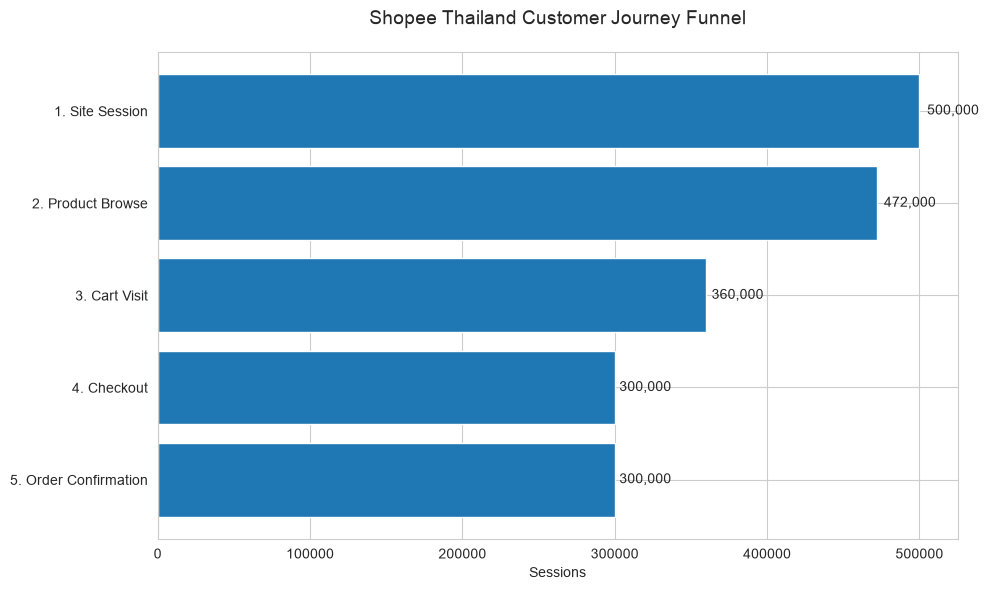

In [52]:
# ============================================================
# 18. Visualization — Customer Journey Funnel
# ============================================================
funnel_plot = funnel_data.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    funnel_plot["stage"],
    funnel_plot["session_count"]
)
ax.set_title(
    "Shopee Thailand Customer Journey Funnel",
    fontsize=14,
    pad=20
)
ax.set_xlabel("Sessions")

for index, value in enumerate(funnel_plot["session_count"]):
    ax.text(
        value * 1.01,
        index,
        f"{value:,}",
        va="center"
    )

plt.tight_layout()
plt.savefig(
    os.path.join(IMAGE_PATH, "01_customer_journey_funnel.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

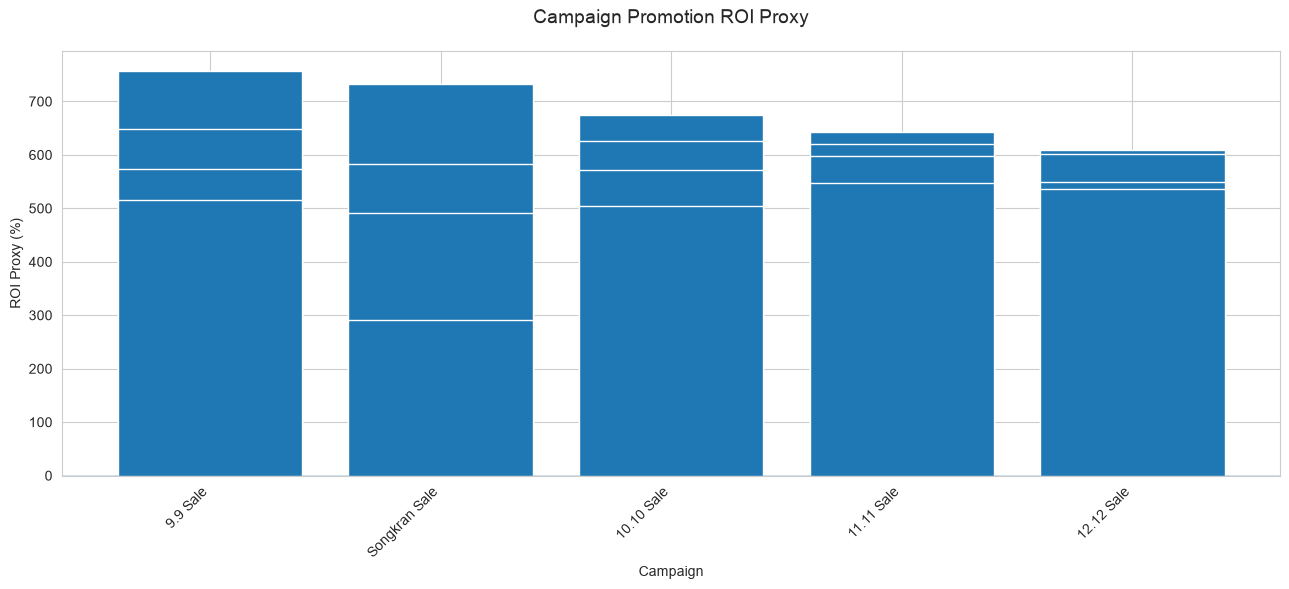

In [53]:
# ============================================================
# 19. Visualization — Campaign ROI
# ============================================================
campaign_plot = campaign_performance.sort_values("promotion_roi_proxy", ascending=False)
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(
    campaign_plot["campaign_name"],
    campaign_plot["promotion_roi_proxy"]
)
ax.axhline(0, linewidth=1)
ax.set_title(
    "Campaign Promotion ROI Proxy",
    fontsize=14,
    pad=20
)
ax.set_xlabel("Campaign")
ax.set_ylabel("ROI Proxy (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(
    os.path.join(IMAGE_PATH, "02_campaign_roi.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

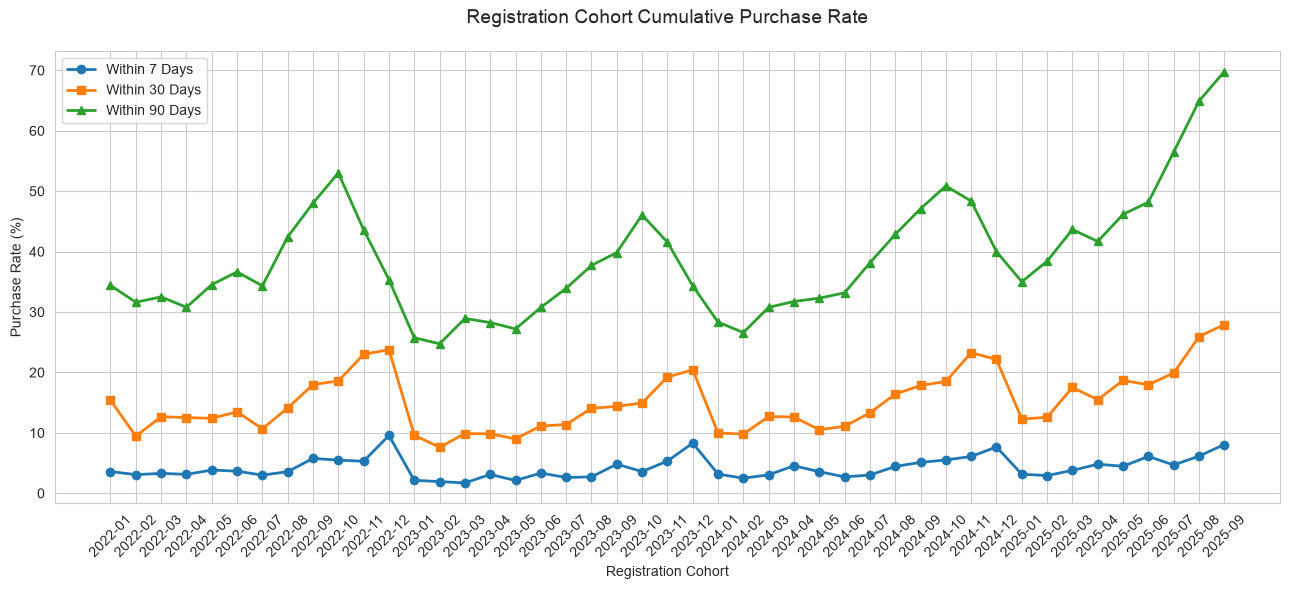

In [54]:
# ============================================================
# 20. Visualization — Cohort
# ============================================================
if not cohort_valid.empty:
    cohort_plot = cohort_valid.copy()
    cohort_plot["cohort"] = cohort_plot["cohort_month"].astype(str)
    
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(
        cohort_plot["cohort"],
        cohort_plot["day_7_purchase_rate"],
        marker="o",
        linewidth=2,
        label="Within 7 Days"
    )
    ax.plot(
        cohort_plot["cohort"],
        cohort_plot["day_30_purchase_rate"],
        marker="s",
        linewidth=2,
        label="Within 30 Days"
    )
    ax.plot(
        cohort_plot["cohort"],
        cohort_plot["day_90_purchase_rate"],
        marker="^",
        linewidth=2,
        label="Within 90 Days"
    )
    ax.set_title(
        "Registration Cohort Cumulative Purchase Rate",
        fontsize=14,
        pad=20
    )
    ax.set_xlabel("Registration Cohort")
    ax.set_ylabel("Purchase Rate (%)")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        os.path.join(IMAGE_PATH, "03_cohort_purchase_rate.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

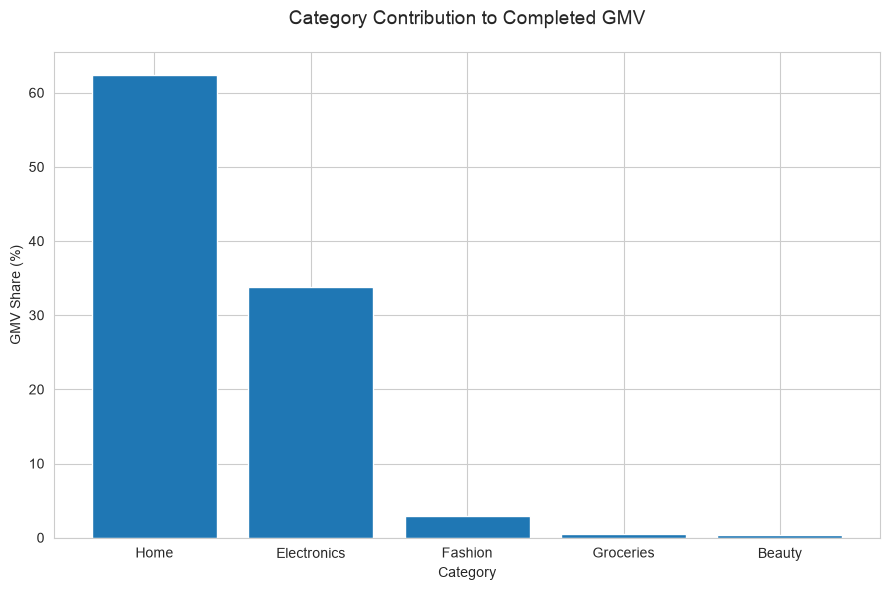

In [55]:
# ============================================================
# 21. Visualization — Category
# ============================================================
category_plot = category_analysis.sort_values("gmv_share_pct", ascending=False)
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(
    category_plot["category"],
    category_plot["gmv_share_pct"]
)
ax.set_title(
    "Category Contribution to Completed GMV",
    fontsize=14,
    pad=20
)
ax.set_xlabel("Category")
ax.set_ylabel("GMV Share (%)")
plt.tight_layout()
plt.savefig(
    os.path.join(IMAGE_PATH, "04_category_gmv_share.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

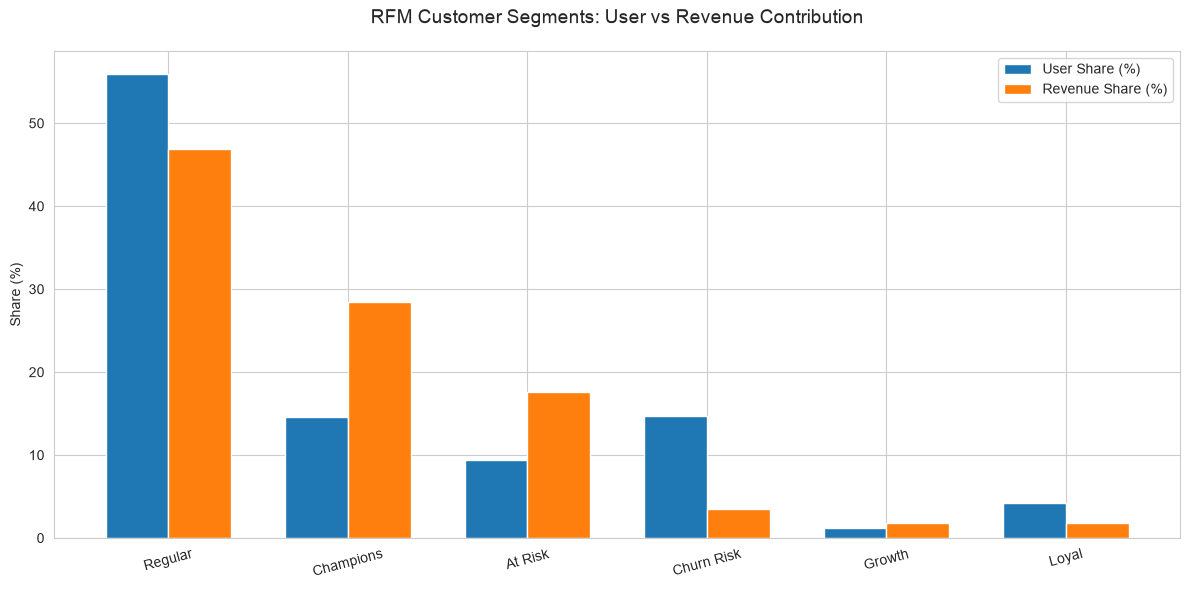

In [56]:
# ============================================================
# 22. Visualization — RFM
# ============================================================
rfm_plot = segment_summary.copy()
x = np.arange(len(rfm_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    x - width / 2,
    rfm_plot["user_share_pct"],
    width,
    label="User Share (%)"
)
ax.bar(
    x + width / 2,
    rfm_plot["revenue_share_pct"],
    width,
    label="Revenue Share (%)"
)
ax.set_xticks(x)
ax.set_xticklabels(
    rfm_plot["segment"],
    rotation=15
)
ax.set_ylabel("Share (%)")
ax.set_title(
    "RFM Customer Segments: User vs Revenue Contribution",
    fontsize=14,
    pad=20
)
ax.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(IMAGE_PATH, "05_rfm_segments.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

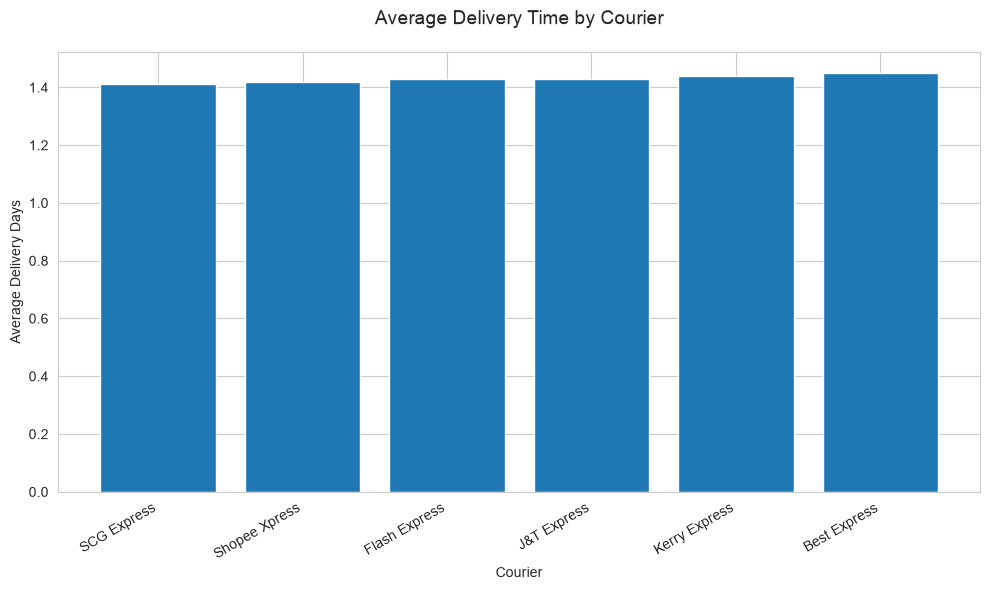

In [57]:
# ============================================================
# 23. Visualization — Courier
# ============================================================
courier_plot = courier_analysis.sort_values("avg_delivery_days")

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    courier_plot["courier_name"],
    courier_plot["avg_delivery_days"]
)
ax.set_title(
    "Average Delivery Time by Courier",
    fontsize=14,
    pad=20
)
ax.set_xlabel("Courier")
ax.set_ylabel("Average Delivery Days")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    os.path.join(IMAGE_PATH, "06_courier_delivery.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [58]:
# ============================================================
# 24. Export Analytical Tables
# ============================================================
EXPORT_TABLES = {
    "funnel_analysis.csv": funnel_data,
    "campaign_attribution_summary.csv": attribution_summary,
    "campaign_period_performance.csv": period_performance,
    "campaign_performance.csv": campaign_performance,
    "cohort_purchase_rate.csv": cohort_valid,
    "category_analysis.csv": category_analysis,
    "seller_analysis.csv": seller_analysis,
    "seller_type_analysis.csv": seller_type_analysis,
    "courier_analysis.csv": courier_analysis,
    "logistics_category_analysis.csv": logistics_category_analysis,
    "rfm_customers.csv": rfm,
    "rfm_segment_summary.csv": segment_summary,
}

print("\n" + "=" * 100)
print("💾 EXPORTING ANALYTICAL RESULTS")
print("=" * 100)
for filename, result_df in EXPORT_TABLES.items():
    output_path = os.path.join(RESULT_PATH, filename)
    result_df.to_csv(output_path, index=False)
    print(f"✅ {filename}")
print("=" * 100)


💾 EXPORTING ANALYTICAL RESULTS
✅ funnel_analysis.csv
✅ campaign_attribution_summary.csv
✅ campaign_period_performance.csv
✅ campaign_performance.csv
✅ cohort_purchase_rate.csv
✅ category_analysis.csv
✅ seller_analysis.csv
✅ seller_type_analysis.csv
✅ courier_analysis.csv
✅ logistics_category_analysis.csv
✅ rfm_customers.csv
✅ rfm_segment_summary.csv


In [59]:
# ============================================================
# 25. Final Dataset Summary
# ============================================================
print("\n" + "=" * 100)
print("✅ SHOPEE THAILAND ANALYTICS PROJECT COMPLETED")
print("=" * 100)
print("\n📊 Dataset Scale")
print(f"Customers:           {customers['customer_id'].nunique():,}")
print(f"Orders:              {orders['order_id'].nunique():,}")
print(f"Order Items:         {len(order_items):,}")
print(f"Completed Items:     {len(completed_items):,}")
print(f"Website Sessions:    {website_sessions['session_id'].nunique():,}")
print(f"Campaigns:           {campaigns['campaign_id'].nunique():,}")
print(f"Sellers:             {sellers['seller_id'].nunique():,}")
print("\n📈 Analysis Modules:")
print("1. Customer Journey Funnel")
print("2. Campaign Performance")
print("3. Registration Cohort Purchase Analysis")
print("4. Category Performance")
print("5. Seller Performance")
print("6. Courier Logistics Performance")
print("7. RFM Customer Segmentation")
print("\n📁 Charts saved to:")
print(IMAGE_PATH)
print("\n📁 Tables saved to:")
print(RESULT_PATH)
print("=" * 100)



✅ SHOPEE THAILAND ANALYTICS PROJECT COMPLETED

📊 Dataset Scale
Customers:           60,000
Orders:              300,000
Order Items:         480,481
Completed Items:     360,187
Website Sessions:    500,000
Campaigns:           20
Sellers:             200

📈 Analysis Modules:
1. Customer Journey Funnel
2. Campaign Performance
3. Registration Cohort Purchase Analysis
4. Category Performance
5. Seller Performance
6. Courier Logistics Performance
7. RFM Customer Segmentation

📁 Charts saved to:
../Images/

📁 Tables saved to:
../Results/
